## Group 7

```
Raymond Julius (5025241268)
Muhammad Zaky Zein (5025241148)
A. Wildan Kevin Assyauqi (5025241265)
M. Fathan Haiban (5025241045)
M. Hilman Azhar (5025241264)
Danzel daniels (5025241228)
```


# Objective

The objective of this analysis is to identify natural groupings of apartments based on their characteristics (price, number of bedrooms, number of bathrooms, and square footage) using clustering techniques. The performance of K-Means and Agglomerative Clustering is compared using SSE and Silhouette Coefficient to determine the most effective clustering method.

# Import

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings

warnings.filterwarnings('ignore')

# Read Data & Cleaning
Load the data, with only the relevant numerical features: price, number of bedrooms, number of bathrooms, and square footage. These variables represent the main characteristics of an apartment and are suitable for clustering analysis.

Next, the dataset is cleaned by removing rows that contain missing values in those selected features. This step ensures that the data used in the analysis is complete and prevents errors or distortions in the clustering process.


In [ ]:
df = pd.read_csv('apartments_for_rent_classified_10K.csv', sep=';', encoding='ISO-8859-1')
features = ['price', 'bedrooms', 'bathrooms', 'square_feet']
df_clean = df[features].dropna()

print(f"The number of data after cleaning: {df_clean.shape[0]}")

The number of data after cleaning: 9960


# Heatmap Feature Correlation
This visualization helps identify patterns or relationships between apartment features, which is useful for understanding the dataset before applying clustering algorithms.

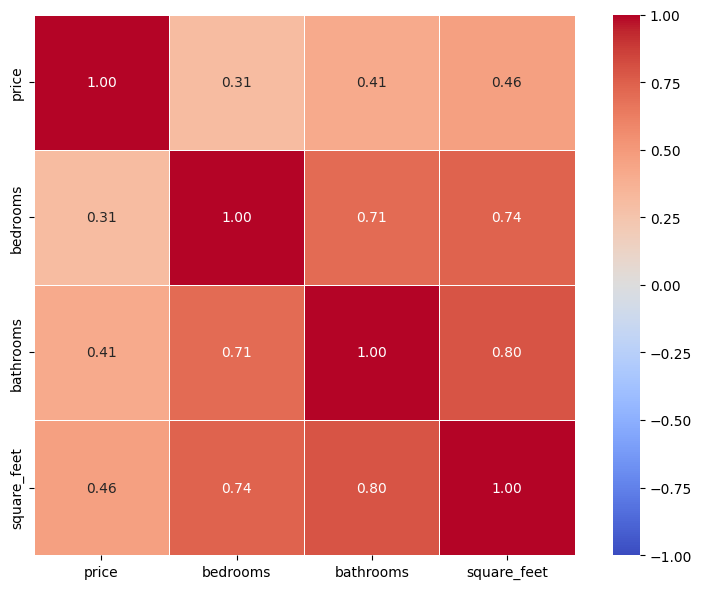

In [ ]:
plt.figure(figsize=(8, 6))
corr_matrix = df_clean.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5, square=True, vmin=-1, vmax=1)
plt.tight_layout()
plt.show()

# Features Distribution Histrogram

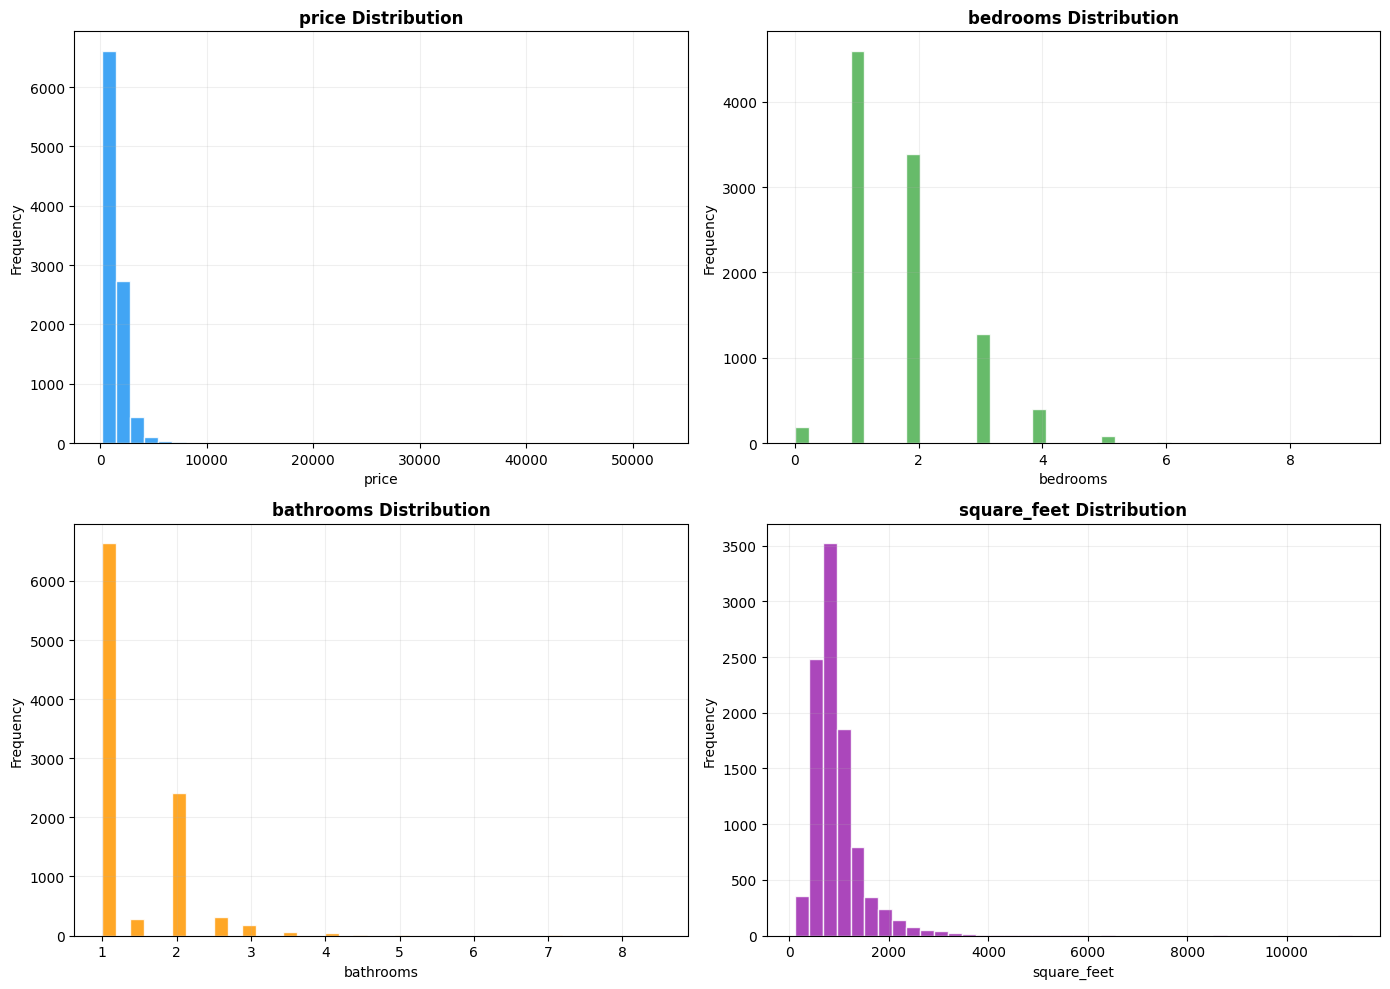

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

for i, (feature, color) in enumerate(zip(features, colors)):
    ax = axes[i // 2, i % 2]
    ax.hist(df_clean[feature], bins=40, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(f'{feature} Distribution', fontsize=12, fontweight='bold')
    ax.set_xlabel(feature)
    ax.set_ylabel('Frequency')
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

# Features Boxplot
Each boxplot summarizes the data using the median, quartiles, and potential outliers. This visualization helps identify skewed distributions, variability, and extreme values in the dataset.

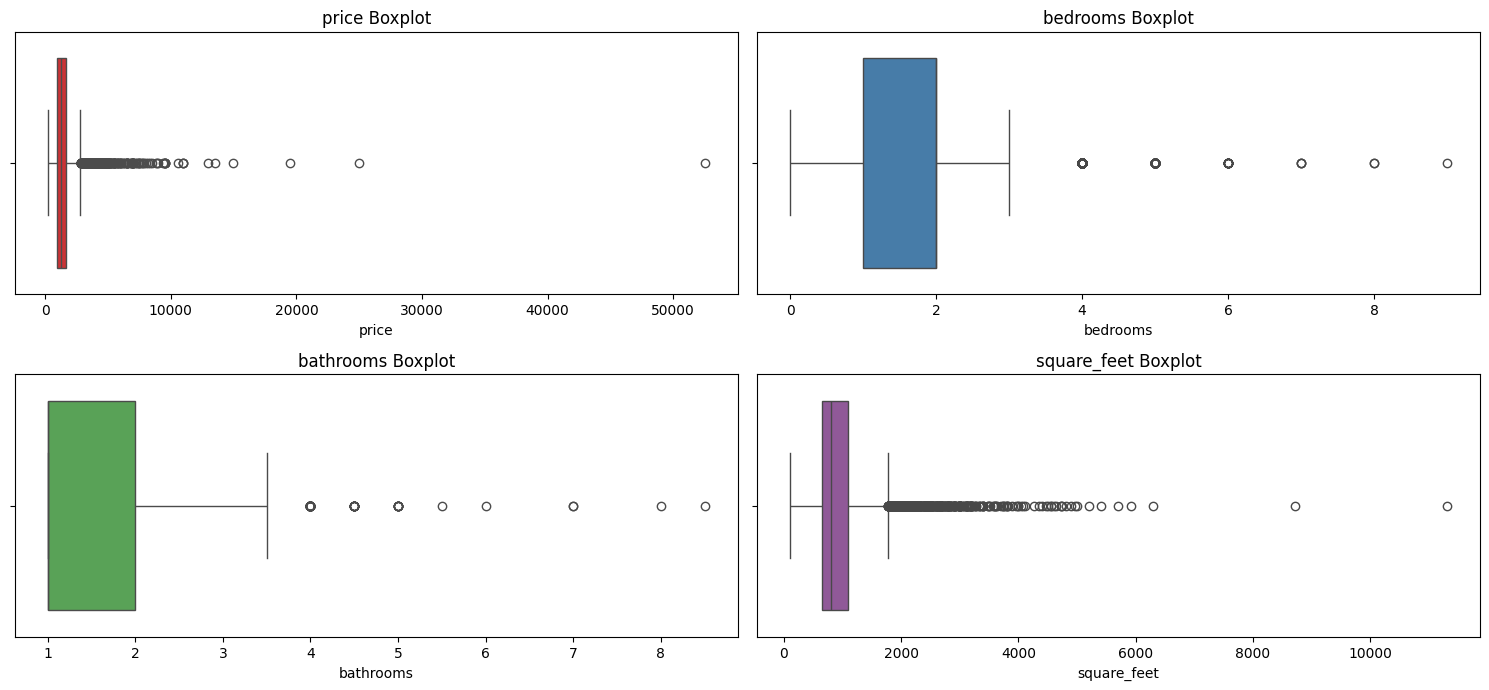

In [ ]:
color_palette = sns.color_palette("Set1", len(features))
plt.figure(figsize=(15, 10))

for i, column in enumerate(features, 1):
    plt.subplot((len(features) // 2) + 1, 2, i)
    sns.boxplot(data=df_clean, x=column, color=color_palette[i - 1])
    plt.xlabel(column)
    plt.title(f'{column} Boxplot')

plt.tight_layout()
plt.show()

# Scaling
Implementing StandardScaler ensures that every variable in dataset contributes equally to the final analysis by removing the bias inherent in different units of measurement.

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean)

# Cluster Calculation

In [ ]:
def calculate_sse_manual(data, labels):
    centroids = np.array([data[labels == l].mean(axis=0) for l in np.unique(labels)])
    return np.sum([np.sum((data[labels == l] - centroids[i])**2) for i, l in enumerate(np.unique(labels))])

k_range = range(2, 7)
km_results = []
agg_results = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km_labels = km.fit_predict(X_scaled)
    km_results.append({'k': k, 'SSE': km.inertia_, 'Silhouette': silhouette_score(X_scaled, km_labels)})

    agg = AgglomerativeClustering(n_clusters=k)
    agg_labels = agg.fit_predict(X_scaled)
    agg_results.append({'k': k, 'SSE': calculate_sse_manual(X_scaled, agg_labels), 'Silhouette': silhouette_score(X_scaled, agg_labels)})

km_df = pd.DataFrame(km_results)
agg_df = pd.DataFrame(agg_results)

# Visualization of calculation results


K-Means Score:
 k  Silhouette          SSE
 2    0.523929 22370.305580
 3    0.508097 16900.850020
 4    0.489011 14667.661313
 5    0.424728 12516.685838
 6    0.426627 10741.464000
------------------------------
Agglomerative Score:
 k  Silhouette          SSE
 2    0.506527 23101.092437
 3    0.503780 17861.382149
 4    0.396268 15541.658547
 5    0.396625 13515.698493
 6    0.408070 11510.371625
------------------------------


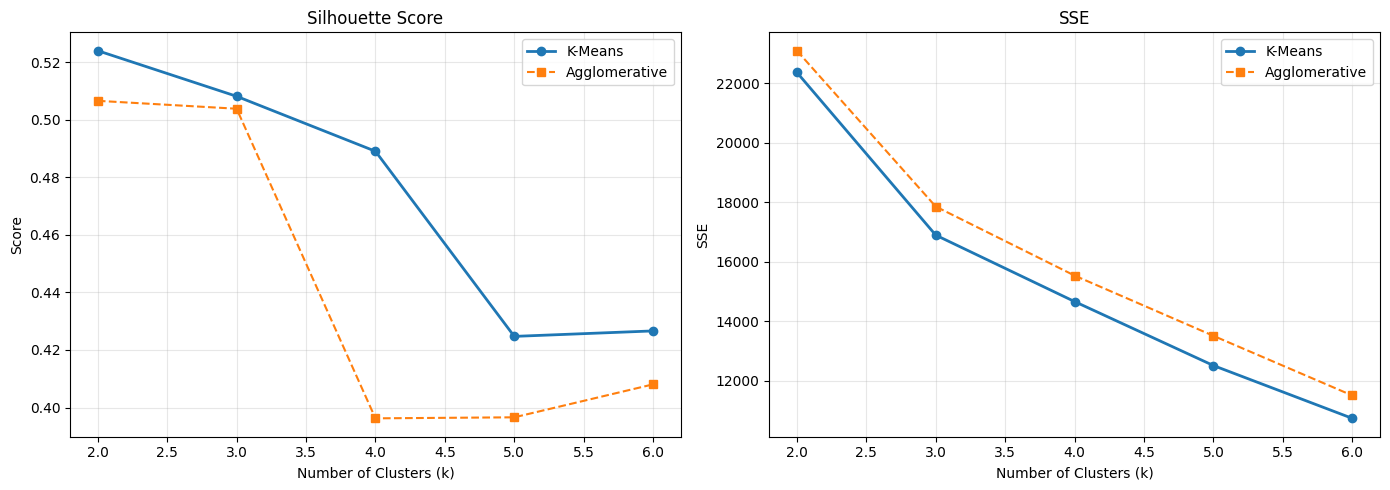

In [ ]:
plt.figure(figsize=(14, 5))

print("K-Means Score:")
print(km_df[['k', 'Silhouette', 'SSE']].to_string(index=False))
print("-" * 30)
print("Agglomerative Score:")
print(agg_df[['k', 'Silhouette', 'SSE']].to_string(index=False))
print("-" * 30)

plt.subplot(1, 2, 1)
plt.plot(km_df['k'], km_df['Silhouette'], label='K-Means', marker='o', linewidth=2)
plt.plot(agg_df['k'], agg_df['Silhouette'], label='Agglomerative', marker='s', linestyle='--')
plt.title('Silhouette Score')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Score')
plt.legend()
plt.grid(True, alpha=0.3)


plt.subplot(1, 2, 2)
plt.plot(km_df['k'], km_df['SSE'], label='K-Means', marker='o', linewidth=2)
plt.plot(agg_df['k'], agg_df['SSE'], label='Agglomerative', marker='s', linestyle='--')
plt.title('SSE')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('SSE')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Obtained Best K = 3
To determine the best value for K, we look for the point where the Silhouette Score is high and the SSE begins to level off. The Silhouette graph shows that K=2 provides the highest separation, but K=3 remains a very strong choice before the score drops sharply at K=4. Meanwhile, the SSE graph exhibits a clear elbow at K=3, indicating that adding more clusters beyond this point yields diminishing returns in reducing error. Because K-Means consistently maintains a higher Silhouette Score and lower SSE than Agglomerative clustering across these points, K-Means with K=3 is the most optimal configuration. This choice successfully balances tight internal grouping with distinct separation between the apartment categories.

In [ ]:
best_k = 3

# Dendrogram Agglomerative Clustering

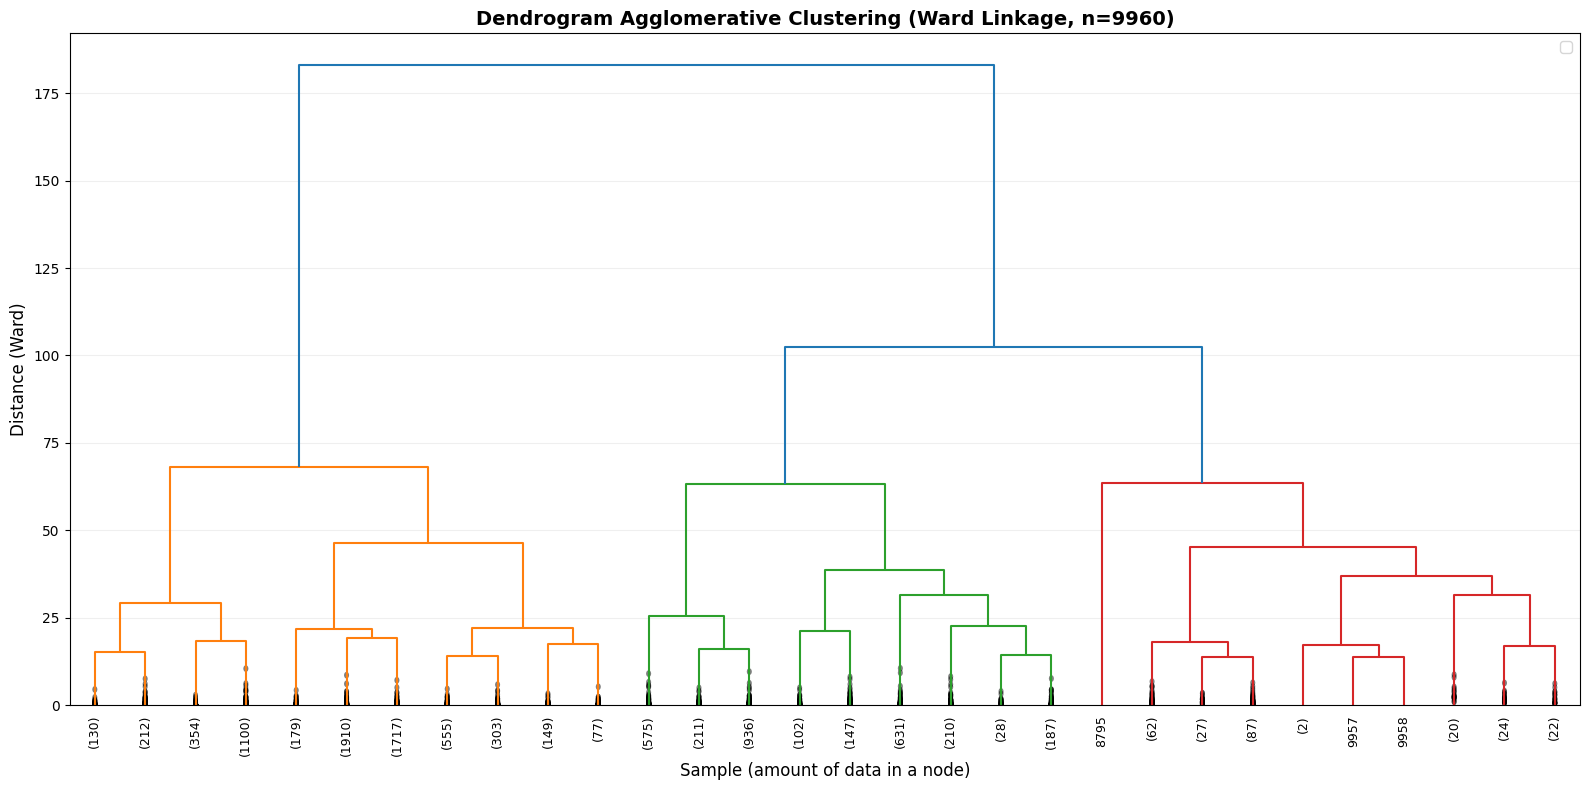

In [ ]:
linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(16, 8))
dn = dendrogram(
    linked,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=90,
    leaf_font_size=9,
    show_contracted=True,
    color_threshold=linked[-(best_k - 1), 2]
)

plt.title(f'Dendrogram Agglomerative Clustering (Ward Linkage, n={len(df_clean)})',
          fontsize=14, fontweight='bold')
plt.xlabel('Sample (amount of data in a node)', fontsize=12)
plt.ylabel('Distance (Ward)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.2, axis='y')
plt.tight_layout()
plt.show()

# Clustering K-Means

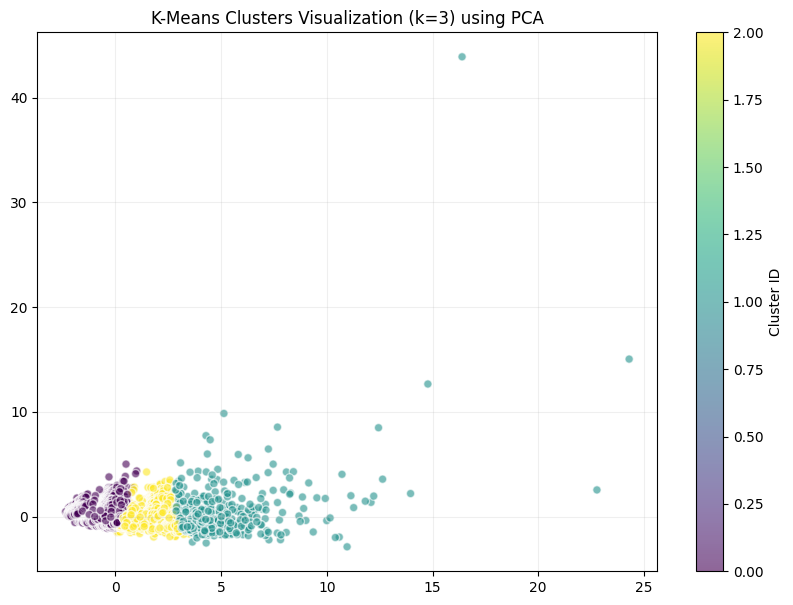

In [ ]:
final_km = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df_clean['kmeans_cluster'] = final_km.fit_predict(X_scaled)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df_clean['kmeans_cluster'], cmap='viridis', alpha=0.6, edgecolors='w')
plt.title(f'K-Means Clusters Visualization (k={best_k}) using PCA')
plt.colorbar(scatter, label='Cluster ID')
plt.grid(True, alpha=0.2)
plt.show()

# Clustering Result
The clustering analysis reveals a clear segmentation of the apartment market into three distinct tiers based on price, size, and room count. Cluster 0 represents the "Budget or Studio" segment, characterized by the lowest average price of approximately 1,245 and the smallest footprint at roughly 691 square feet, typically catering to individuals or students. In contrast, Cluster 2 functions as the "Mid-Range" or "Family" category, offering a balanced profile with an average price of 1,684 and nearly double the space at 1,252 square feet, which accommodates 2 to 3 bedrooms. Finally, Cluster 1 stands out as the "Premium or Luxury" segment, where the price jumps significantly to an average of 3,666. These high-end units are substantially larger, averaging 2,536 square feet with approximately 4 bedrooms and 3 bathrooms, indicating they target an upscale market or large families seeking significant space. Overall, the K-Means algorithm effectively captured a linear relationship where price increases in tandem with physical dimensions and room utility across the dataset.

In [ ]:
cluster_summary = df_clean.groupby('kmeans_cluster')[features].mean().round(2)
print(f"\nClustering results (all {len(df_clean)} data):")
cluster_summary


Clustering results (all 9960 data):


,price,bedrooms,bathrooms,square_feet
kmeans_cluster,,,,
0,1245.36,1.26,1.01,691.07
1,3666.64,3.94,2.95,2536.17
2,1684.48,2.47,1.96,1252.21


# Data Proportion per Cluster

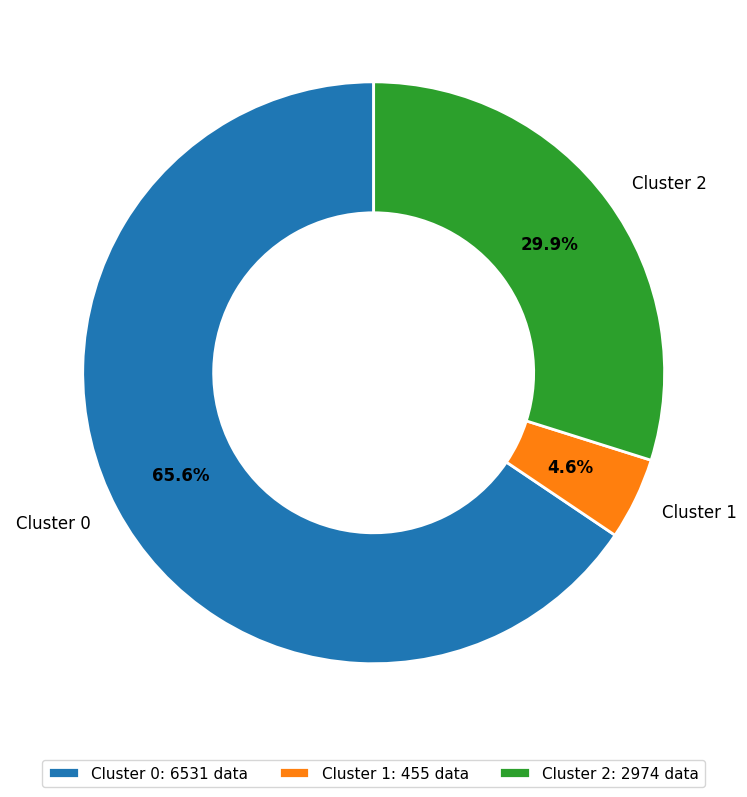

In [ ]:
cluster_counts = df_clean['kmeans_cluster'].value_counts().sort_index()
cluster_colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(
    cluster_counts.values,
    labels=[f'Cluster {i}' for i in cluster_counts.index],
    autopct='%1.1f%%',
    colors=cluster_colors,
    startangle=90,
    pctdistance=0.75,
    wedgeprops=dict(width=0.45, edgecolor='white', linewidth=2)
)

for autotext in autotexts:
    autotext.set_fontsize(12)
    autotext.set_fontweight('bold')
for text in texts:
    text.set_fontsize(12)

legend_labels = [f'Cluster {i}: {count} data' for i, count in zip(cluster_counts.index, cluster_counts.values)]
ax.legend(legend_labels, loc='lower center', bbox_to_anchor=(0.5, -0.08), ncol=best_k, fontsize=11)

plt.tight_layout()
plt.show()